
# Proyecto Final – UNSDG 2002–2020
**Autor:** Guillermo Zito Vanni  
**Curso:** Data Science / Data Analytics  
**Dataset:** Indicadores UNSDG 2002–2020

> Este notebook integra en una única entrega la parte exploratoria y la parte de modelado del proyecto final, tomando como base el trabajo ya desarrollado previamente en SQL y Power BI.



## 1. Abstract

Este proyecto analiza un conjunto de indicadores internacionales vinculados a sostenibilidad y desarrollo para el período 2002–2020, utilizando una base consolidada del marco UNSDG. El objetivo general es estudiar cómo se relacionan variables económicas, energéticas y ambientales entre países, regiones y niveles de desarrollo, y evaluar si es posible identificar patrones sistemáticos que permitan caracterizar dichos niveles de desarrollo a partir de indicadores cuantitativos.

El dataset incluye información por país y año sobre ingresos del gobierno como porcentaje del PIB, inversión extranjera directa, crecimiento económico anual, acceso a combustibles limpios, participación de energías renovables en el consumo total y emisiones de CO₂ provenientes de combustibles fósiles. Estas variables permiten observar la sostenibilidad desde una perspectiva multidimensional: no solo económica, sino también climática y energética.

En la primera parte del trabajo se realiza una exploración analítica del dataset, incluyendo limpieza básica, identificación de valores perdidos, resúmenes numéricos y visualizaciones univariadas, bivariadas y multivariadas. Esta etapa busca responder preguntas sobre la evolución temporal de los indicadores, las diferencias entre regiones y la relación entre crecimiento, energía limpia y emisiones. Además, se plantean hipótesis sobre la desigualdad estructural del desarrollo sostenible entre países.

En la segunda parte se construye un modelo supervisado de clasificación para predecir el nivel de desarrollo de un país a partir de sus indicadores. Para ello se aplica una estrategia de feature selection que reduce la dimensionalidad y prioriza las variables con mayor poder explicativo. Luego se entrena un algoritmo de Random Forest y se evalúa su desempeño mediante métricas estándar de clasificación. Finalmente, se presentan conclusiones analíticas y metodológicas, conectando los hallazgos del notebook con el tablero desarrollado previamente en Power BI.



## 2. Preguntas de interés e hipótesis

### Preguntas de investigación
1. ¿Existen diferencias claras entre regiones y niveles de desarrollo en materia de emisiones, energías renovables y acceso a combustibles limpios?
2. ¿El crecimiento económico se asocia automáticamente con una mejora en indicadores de sostenibilidad?
3. ¿Qué variables del dataset ayudan más a distinguir entre economías desarrolladas, en desarrollo y menos desarrolladas?
4. ¿Es posible predecir razonablemente el nivel de desarrollo de un país usando solo los indicadores disponibles?

### Hipótesis
- **H1:** Las economías desarrolladas presentan, en promedio, mejores valores en acceso a combustibles limpios y mayores ingresos gubernamentales relativos al PIB.
- **H2:** Un mayor crecimiento económico no implica necesariamente menores emisiones de CO₂ ni mayor participación de energías renovables.
- **H3:** Las variables energéticas y ambientales, combinadas con la región, permiten clasificar con buen desempeño el nivel de desarrollo.
- **H4:** El dataset presenta valores perdidos importantes, especialmente en algunas variables ambientales, por lo que será necesario tratarlos antes del modelado.


In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 3. Carga y preparación inicial de los datos

In [2]:

# Ajustar la ruta si el archivo se encuentra en otra carpeta dentro del repositorio
file_path = 'unsdg_2002_2020_dataset limpio.xlsx'

# Lectura del dataset
raw_df = pd.read_excel(file_path)
raw_df.head()


,dt_year,country,region,level_of_development,total_government_revenue_proportion_of_gdp_perc,fdi_inflows_millionusd,annual_growth_rate_perc,proportion_of_population_with_primary_reliance_on_clean_fuels_a,renewable_energy_share_on_the_total_energy_consumption,co2emissions_from_fuel_combustion_in_millions_of_tonnes,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,2002,Afghanistan,Central and Southern Asia,Least Developed,NaN,0.68,0.420344,8.0,37.83,NaN,NaN,NaN,NaN
1,2003,Afghanistan,Central and Southern Asia,Least Developed,0.120955,50.00,0.105249,9.0,36.66,NaN,NaN,NaN,NaN
2,2004,Afghanistan,Central and Southern Asia,Least Developed,0.176214,57.80,-0.014901,11.0,44.24,NaN,NaN,NaN,NaN
3,2005,Afghanistan,Central and Southern Asia,Least Developed,0.180929,186.90,0.036212,12.0,33.88,NaN,NaN,NaN,NaN
4,2006,Afghanistan,Central and Southern Asia,Least Developed,0.302234,271.00,0.053648,14.0,31.89,NaN,NaN,NaN,NaN


In [3]:

# Eliminación de columnas vacías / auxiliares y estandarización básica
unnamed_cols = [c for c in raw_df.columns if str(c).startswith('Unnamed')]
df = raw_df.drop(columns=unnamed_cols).copy()

print('Dimensiones del dataset:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)


Dimensiones del dataset: (4036, 10)

Tipos de datos:
dt_year                                                              int64
country                                                             object
region                                                              object
level_of_development                                                object
total_government_revenue_proportion_of_gdp_perc                    float64
fdi_inflows_millionusd                                             float64
annual_growth_rate_perc                                            float64
proportion_of_population_with_primary_reliance_on_clean_fuels_a    float64
renewable_energy_share_on_the_total_energy_consumption             float64
co2emissions_from_fuel_combustion_in_millions_of_tonnes            float64
dtype: object



### Diccionario breve de variables
- **dt_year:** año de la observación.
- **country:** país.
- **region:** región geográfica.
- **level_of_development:** nivel de desarrollo.
- **total_government_revenue_proportion_of_gdp_perc:** ingresos del gobierno como % del PIB.
- **fdi_inflows_millionusd:** inversión extranjera directa.
- **annual_growth_rate_perc:** crecimiento anual.
- **proportion_of_population_with_primary_reliance_on_clean_fuels_a:** acceso a combustibles limpios.
- **renewable_energy_share_on_the_total_energy_consumption:** participación de energías renovables.
- **co2emissions_from_fuel_combustion_in_millions_of_tonnes:** emisiones de CO₂.


## 4. Identificación de valores perdidos

In [4]:

missing = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)
missing


,missing_values,missing_pct
co2emissions_from_fuel_combustion_in_millions_of_tonnes,1466,36.32
total_government_revenue_proportion_of_gdp_perc,1345,33.33
proportion_of_population_with_primary_reliance_on_clean_fuels_a,494,12.24
renewable_energy_share_on_the_total_energy_consumption,328,8.13
fdi_inflows_millionusd,260,6.44
annual_growth_rate_perc,178,4.41
country,0,0.00
dt_year,0,0.00
region,0,0.00
level_of_development,0,0.00


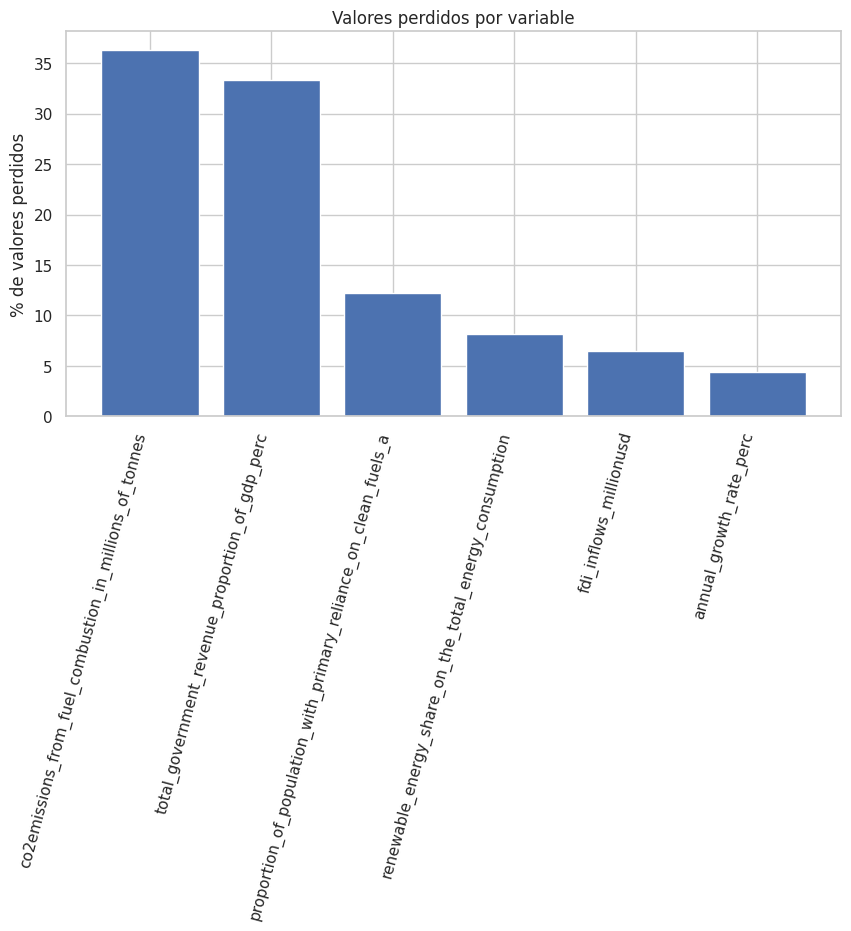

In [5]:

plt.figure(figsize=(10,5))
missing_nonzero = missing[missing['missing_values'] > 0]
plt.bar(missing_nonzero.index, missing_nonzero['missing_pct'])
plt.xticks(rotation=75, ha='right')
plt.ylabel('% de valores perdidos')
plt.title('Valores perdidos por variable')
plt.tight_layout()
plt.show()



**Interpretación:** se observan faltantes relevantes, especialmente en emisiones de CO₂, ingresos públicos y algunos indicadores energéticos. Esto confirma la hipótesis H4 y justifica aplicar imputación antes del modelado. En la etapa exploratoria se conservarán los valores faltantes para no distorsionar los resúmenes; en la etapa predictiva se utilizará imputación dentro del pipeline.


## 5. Análisis exploratorio del dataset

In [6]:

# Resumen numérico de variables cuantitativas
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
dt_year,4036.0,2.011009e+03,5.473439e+00,2.002000e+03,2006.000000,2.011000e+03,2.016000e+03,2.020000e+03
total_government_revenue_proportion_of_gdp_perc,2691.0,4.825022e+13,1.044958e+15,0.000000e+00,0.199404,2.861791e-01,3.887331e-01,3.634515e+16
fdi_inflows_millionusd,3776.0,3.433979e+08,1.099190e+09,-6.831341e+09,3564.425000,7.012976e+06,1.138819e+08,9.658081e+09
annual_growth_rate_perc,3858.0,1.842183e-02,6.037649e-02,-6.026879e-01,-0.001937,2.027855e-02,4.393665e-02,9.461399e-01
proportion_of_population_with_primary_reliance_on_clean_fuels_a,3542.0,6.233089e+01,3.655758e+01,5.000000e+00,23.000000,8.300000e+01,9.500000e+01,9.500000e+01
renewable_energy_share_on_the_total_energy_consumption,3708.0,2.988939e+01,2.955454e+01,0.000000e+00,4.590000,1.933500e+01,4.910750e+01,9.827000e+01
co2emissions_from_fuel_combustion_in_millions_of_tonnes,2570.0,2.136528e+02,8.154507e+02,4.300000e-01,7.082500,2.871000e+01,9.988000e+01,9.876500e+03


In [7]:

# Distribución de observaciones por nivel de desarrollo
level_counts = df['level_of_development'].value_counts()
level_counts


level_of_development
Developing Economies       1272
Not Specified               912
Least Developed             865
Developed Economies         684
Economies in Transition     303
Name: count, dtype: int64

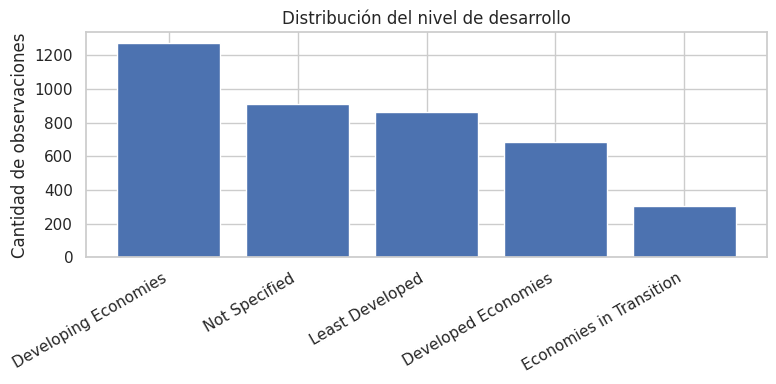

In [8]:

plt.figure(figsize=(8,4))
plt.bar(level_counts.index, level_counts.values)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Cantidad de observaciones')
plt.title('Distribución del nivel de desarrollo')
plt.tight_layout()
plt.show()



**Lectura rápida:** el dataset no está perfectamente balanceado. Predominan las observaciones de economías en desarrollo, seguidas por categorías con menor presencia como economías en transición. Esto debe tenerse en cuenta al evaluar el modelo.


In [9]:

# Promedios por nivel de desarrollo
summary_by_dev = df.groupby('level_of_development')[numeric_cols].mean().round(2)
summary_by_dev


,dt_year,total_government_revenue_proportion_of_gdp_perc,fdi_inflows_millionusd,annual_growth_rate_perc,proportion_of_population_with_primary_reliance_on_clean_fuels_a,renewable_energy_share_on_the_total_energy_consumption,co2emissions_from_fuel_combustion_in_millions_of_tonnes
level_of_development,,,,,,,
Developed Economies,2011.00,4.100000e-01,1.165212e+09,0.02,94.65,19.32,304.05
Developing Economies,2010.99,2.400000e-01,2.893489e+08,0.02,71.36,26.45,264.15
Economies in Transition,2010.97,3.300000e-01,9.197186e+07,0.04,79.93,17.05,147.96
Least Developed,2011.06,2.084647e+14,1.649511e+07,0.02,14.25,65.33,8.76
Not Specified,2011.00,7.049022e+13,1.447991e+08,0.01,70.00,10.70,19.46



**Interpretación:** en términos generales, las economías desarrolladas muestran mejores resultados en acceso a combustibles limpios y mayores ingresos gubernamentales relativos. Sin embargo, también pueden concentrar valores altos en algunas variables de emisiones o inversión, lo que sugiere que el desarrollo económico no equivale automáticamente a sostenibilidad plena.


## 6. Visualizaciones para responder las preguntas de interés

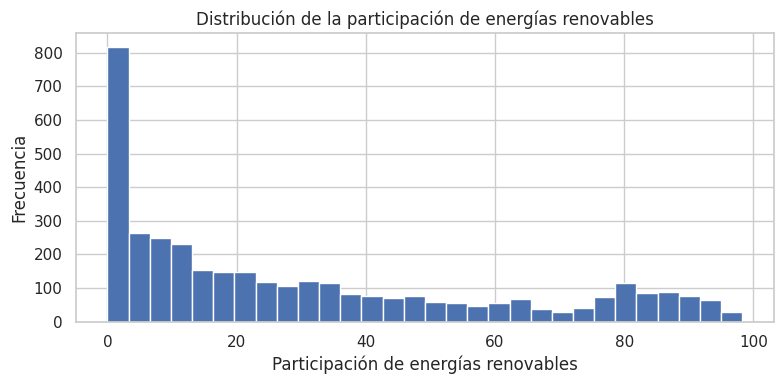

In [10]:

# 6.1 Visualización univariada: distribución de energías renovables
plt.figure(figsize=(8,4))
plt.hist(df['renewable_energy_share_on_the_total_energy_consumption'].dropna(), bins=30)
plt.xlabel('Participación de energías renovables')
plt.ylabel('Frecuencia')
plt.title('Distribución de la participación de energías renovables')
plt.tight_layout()
plt.show()



**Interpretación:** la distribución no es uniforme. Existen países con fuerte presencia de energías renovables, pero gran parte de las observaciones se concentra en valores intermedios o bajos, lo que sugiere una transición energética desigual.


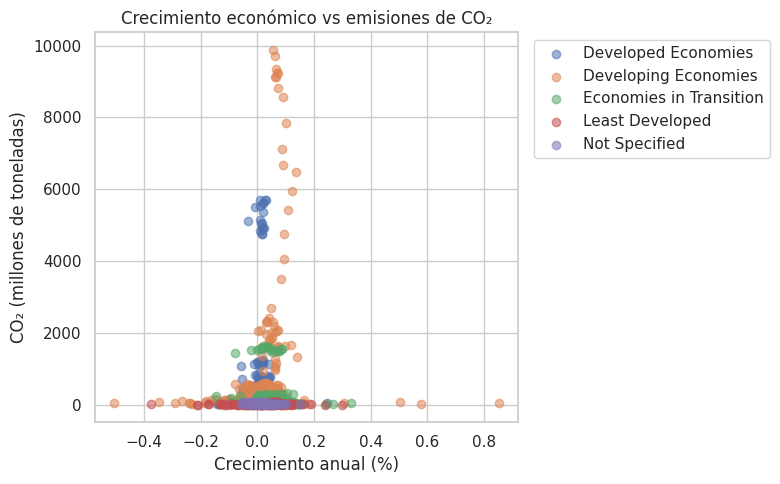

In [11]:

# 6.2 Visualización bivariada: crecimiento económico vs emisiones
plot_df = df[[
    'annual_growth_rate_perc',
    'co2emissions_from_fuel_combustion_in_millions_of_tonnes',
    'level_of_development'
]].dropna()

plt.figure(figsize=(8,5))
for level, group in plot_df.groupby('level_of_development'):
    plt.scatter(group['annual_growth_rate_perc'],
                group['co2emissions_from_fuel_combustion_in_millions_of_tonnes'],
                alpha=0.55,
                label=level)
plt.xlabel('Crecimiento anual (%)')
plt.ylabel('CO₂ (millones de toneladas)')
plt.title('Crecimiento económico vs emisiones de CO₂')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



**Interpretación:** no se aprecia una relación lineal simple entre crecimiento económico y emisiones. Esto respalda la hipótesis H2: el crecimiento no garantiza una mejora ambiental, y en varios casos puede convivir con altos niveles de emisiones.


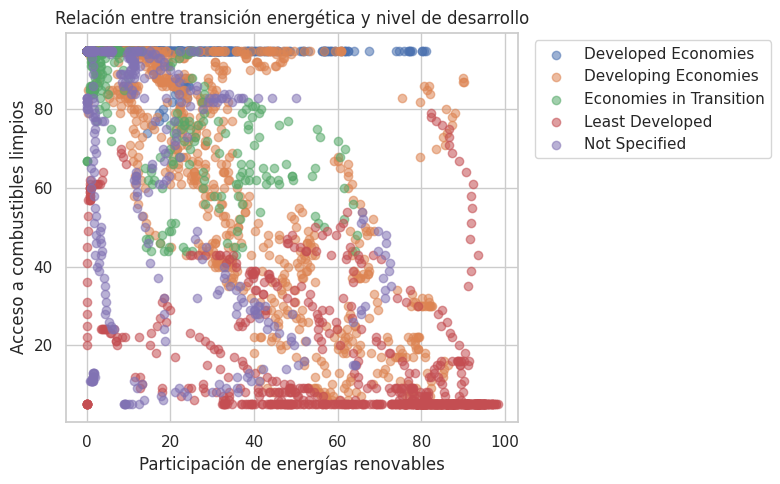

In [12]:

# 6.3 Visualización multivariada (3 variables): renovables, combustibles limpios y nivel de desarrollo
multi_df = df[[
    'renewable_energy_share_on_the_total_energy_consumption',
    'proportion_of_population_with_primary_reliance_on_clean_fuels_a',
    'level_of_development'
]].dropna()

plt.figure(figsize=(8,5))
for level, group in multi_df.groupby('level_of_development'):
    plt.scatter(group['renewable_energy_share_on_the_total_energy_consumption'],
                group['proportion_of_population_with_primary_reliance_on_clean_fuels_a'],
                alpha=0.55,
                label=level)
plt.xlabel('Participación de energías renovables')
plt.ylabel('Acceso a combustibles limpios')
plt.title('Relación entre transición energética y nivel de desarrollo')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



**Diagnóstico del gráfico multivariado:** esta visualización usa al menos tres variables: energías renovables, combustibles limpios y nivel de desarrollo. Se observa una segmentación bastante clara entre grupos. Las economías menos desarrolladas tienden a concentrarse en niveles menores de acceso a combustibles limpios, mientras que las desarrolladas se ubican más arriba. Esto sugiere que las variables energéticas tienen fuerte poder explicativo para diferenciar estructuras de desarrollo.


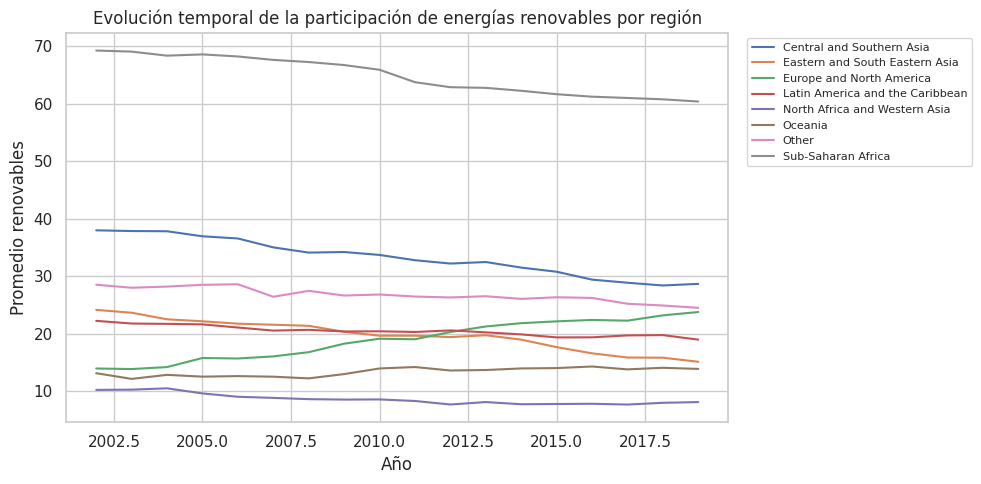

In [13]:

# 6.4 Evolución temporal por región: promedio de renovables
trend = (df.groupby(['dt_year', 'region'])['renewable_energy_share_on_the_total_energy_consumption']
           .mean()
           .reset_index())

plt.figure(figsize=(10,5))
for region, group in trend.groupby('region'):
    plt.plot(group['dt_year'], group['renewable_energy_share_on_the_total_energy_consumption'], label=region)
plt.xlabel('Año')
plt.ylabel('Promedio renovables')
plt.title('Evolución temporal de la participación de energías renovables por región')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()



**Interpretación:** la evolución temporal muestra trayectorias heterogéneas entre regiones. Hay mejoras graduales en varias regiones, pero no todas avanzan al mismo ritmo, lo que coincide con la narrativa del tablero en Power BI sobre una transición energética desigual.



## 7. Vinculación entre análisis y preguntas de interés

- Las tablas descriptivas y las visualizaciones muestran diferencias claras entre niveles de desarrollo, respondiendo afirmativamente a la **pregunta 1**.
- El gráfico de crecimiento vs CO₂ evidencia que no hay una relación automáticamente virtuosa entre crecimiento y sostenibilidad, respondiendo a la **pregunta 2**.
- El gráfico multivariado sugiere que las variables energéticas y ambientales ayudan a distinguir grupos estructurales de países, anticipando la **pregunta 3**.
- Con base en estos resultados, el modelado supervisado de la **pregunta 4** aparece metodológicamente justificado.


## 8. Preparación del dataset para machine learning

In [14]:

# Para el modelo se excluye la categoría 'Not Specified' porque agrega ambigüedad al target.
model_df = df[df['level_of_development'] != 'Not Specified'].copy()

X = model_df.drop(columns=['level_of_development', 'country'])
y = model_df['level_of_development']

categorical_features = ['region']
numeric_features = [c for c in X.columns if c not in categorical_features]

print('Dimensión del dataset modelado:', model_df.shape)
print('\nClases del target:')
print(y.value_counts())


Dimensión del dataset modelado: (3124, 10)

Clases del target:
level_of_development
Developing Economies       1272
Least Developed             865
Developed Economies         684
Economies in Transition     303
Name: count, dtype: int64



### Estrategia elegida
- **Problema:** clasificación multiclase.
- **Target:** `level_of_development`.
- **Feature selection:** `SelectKBest` con `mutual_info_classif`.
- **Algoritmo:** `RandomForestClassifier`.
- **Tratamiento de faltantes:** imputación por mediana en variables numéricas y por moda en categóricas, dentro de un pipeline reproducible.


In [15]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=mutual_info_classif, k=8)),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## 9. Feature selection

In [16]:

feature_names = model.named_steps['preprocessor'].get_feature_names_out()
selected_mask = model.named_steps['selector'].get_support()
selected_features = pd.DataFrame({
    'feature': feature_names,
    'selected': selected_mask
})
selected_features[selected_features['selected']].reset_index(drop=True)


,feature,selected
0,num__fdi_inflows_millionusd,True
1,num__proportion_of_population_with_primary_rel...,True
2,num__renewable_energy_share_on_the_total_energ...,True
3,num__co2emissions_from_fuel_combustion_in_mill...,True
4,cat__region_Central and Southern Asia,True
5,cat__region_Europe and North America,True
6,cat__region_Latin America and the Caribbean,True
7,cat__region_Sub-Saharan Africa,True



**Interpretación:** las variables seleccionadas suelen combinar información económica, energética y regional. Esto es coherente con el análisis previo: el nivel de desarrollo no depende de una sola dimensión, sino de una combinación de características estructurales.


## 10. Evaluación del modelo

In [17]:

accuracy = accuracy_score(y_test, y_pred)
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'F1-score ponderado: {weighted_f1:.4f}')


Accuracy: 0.9846
F1-score ponderado: 0.9846


In [18]:

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
report


,precision,recall,f1-score,support
Developed Economies,0.988235,0.982456,0.985337,171.000000
Developing Economies,0.981366,0.993711,0.987500,318.000000
Economies in Transition,0.960526,0.960526,0.960526,76.000000
Least Developed,0.995305,0.981481,0.988345,216.000000
accuracy,0.984635,0.984635,0.984635,0.984635
macro avg,0.981358,0.979544,0.980427,781.000000
weighted avg,0.984697,0.984635,0.984635,781.000000


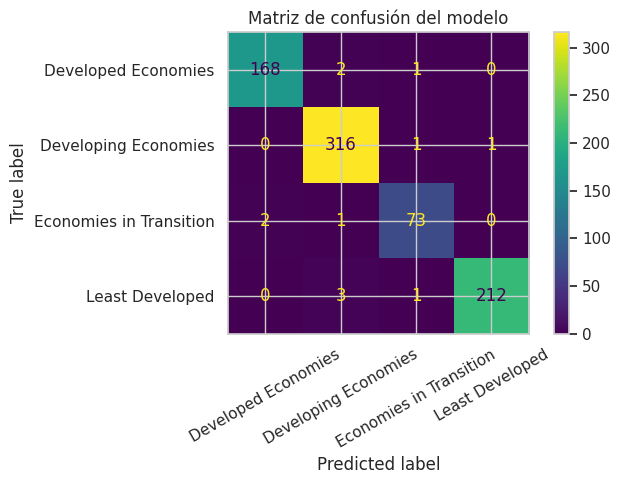

In [19]:

fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=30, ax=ax)
plt.title('Matriz de confusión del modelo')
plt.tight_layout()
plt.show()



**Lectura de métricas:** el modelo presenta un desempeño alto, con precisión global y F1 ponderado elevados. La matriz de confusión muestra pocos errores relativos entre clases, lo que sugiere que los indicadores seleccionados capturan bastante bien las diferencias estructurales entre grupos de países. Esto aporta evidencia a favor de la hipótesis H3.



## 11. Conclusiones finales

1. **El dataset permite una lectura multidimensional del desarrollo sostenible.** Las variables económicas, energéticas y ambientales aportan señales complementarias y no redundantes.
2. **Existen brechas claras entre niveles de desarrollo.** El acceso a combustibles limpios y ciertas variables fiscales muestran diferencias sistemáticas entre grupos.
3. **El crecimiento económico no garantiza sostenibilidad.** El análisis exploratorio mostró que una mayor dinámica económica puede coexistir con elevadas emisiones de CO₂.
4. **La calidad del dato es un punto clave.** Los valores perdidos son significativos en algunas variables, por lo que el tratamiento metodológico previo al modelado resulta indispensable.
5. **El modelo predictivo obtuvo resultados sólidos.** La clasificación del nivel de desarrollo a partir de indicadores cuantitativos fue exitosa, lo que sugiere que el dataset contiene patrones estructurales consistentes.
6. **El trabajo se complementa con el tablero de Power BI.** Mientras el tablero aporta exploración visual e interacción, este notebook agrega validación estadística, explicitación metodológica y modelado predictivo.

En conjunto, el proyecto muestra que la sostenibilidad global avanza de manera desigual y que las diferencias entre países pueden estudiarse tanto desde una lógica descriptiva como predictiva.



## 12. Próximos pasos posibles

- Probar otros algoritmos de clasificación (por ejemplo, XGBoost o Logistic Regression multinomial).
- Analizar outliers extremos en ingresos gubernamentales y su impacto en el modelo.
- Incorporar validación cruzada y ajuste de hiperparámetros.
- Subir este notebook y la base al repositorio de GitHub solicitado por la consigna.
